In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from GitHub_QM.Quantum_Batteries_Scars.paper.helper.quantumScarFunctions import *

In [11]:
N = 4
wm = 1.0
wd = 0.6366896896896898

tlist = np.linspace(0, 50, 100)
dlist = np.linspace(0.0, 2.0, 15)
alist = np.linspace(0.1, 2.5, 15)
reals = 100

qubit: disorder=0.000 done
qubit: disorder=0.143 done
qubit: disorder=0.286 done
qubit: disorder=0.429 done
qubit: disorder=0.571 done
qubit: disorder=0.714 done
qubit: disorder=0.857 done
qubit: disorder=1.000 done
qubit: disorder=1.143 done
qubit: disorder=1.286 done
qubit: disorder=1.429 done
qubit: disorder=1.571 done
qubit: disorder=1.714 done
qubit: disorder=1.857 done
qubit: disorder=2.000 done


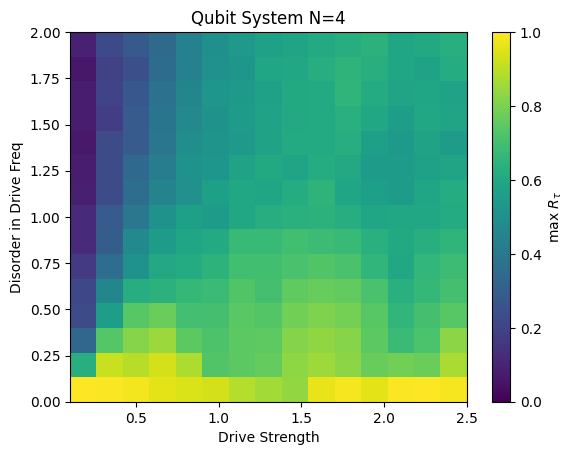

In [12]:
qH0_list, qH1_list, qDriveWeights = get_qubit_ham(N, wm=wm)

q_eigs = [qH0.eigenstates() for qH0 in qH0_list]
bw_tot = sum(ev[-1] - ev[0] for ev, _ in q_eigs)

qdisRtau = []
for disorder in dlist:
    qampRtau = []
    for amp in alist:
        Rtau_qubit = []
        for _ in range(reals):
            omega_list = wm + np.random.uniform(-disorder, disorder, N)

            dE_tot = np.zeros(len(tlist))
            for r in range(N):
                qeigenvalues, qeigenstates = q_eigs[r]

                qH = qt.QobjEvo([qH0_list[r], [qH1_list[r], coeff]],
                                args={"A": amp, "omega": omega_list[r]})
                qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0_list[r]])
                dE_tot += np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

            Rtau_qubit.append(dE_tot / bw_tot)

        qampRtau.append(np.max(np.mean(Rtau_qubit, axis=0)))
    qdisRtau.append(qampRtau)
    print(f"qubit: disorder={disorder:.3f} done")

qdisRtau = np.array(qdisRtau)

plt.imshow(qdisRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label=r"max $R_\tau$")
plt.title(f"Qubit System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.show()

scar: disorder=0.000 done
scar: disorder=0.143 done
scar: disorder=0.286 done
scar: disorder=0.429 done
scar: disorder=0.571 done
scar: disorder=0.714 done
scar: disorder=0.857 done
scar: disorder=1.000 done
scar: disorder=1.143 done
scar: disorder=1.286 done
scar: disorder=1.429 done
scar: disorder=1.571 done
scar: disorder=1.714 done
scar: disorder=1.857 done
scar: disorder=2.000 done


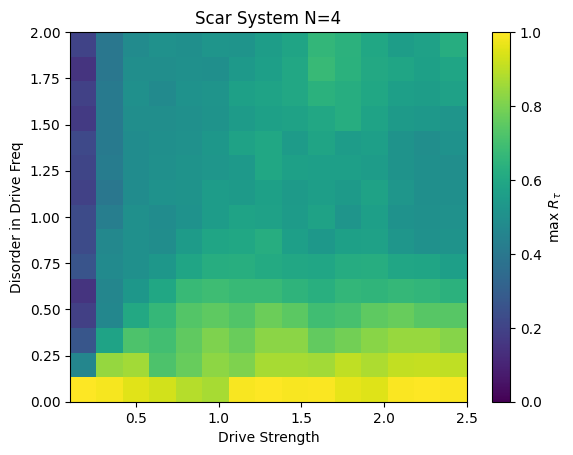

In [13]:
H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1_list, driveWeights = get_scar_H1(N, basisList, ds_dis=0.0, indv_qubit=True)

bandwidth = eigenvalues[-1] - eigenvalues[0]
psi_init = eigenstates[0]

disRtau = []
for disorder in dlist:
    ampRtau = []
    for amp in alist:
        Rtau_scar = []
        for _ in range(reals):
            omega_list = wd + np.random.uniform(-disorder, disorder, N)

            args = {"A": amp}
            H = [H0]
            for r in range(N):
                args[f"wd{r}"] = omega_list[r]
                H.append([H1_list[r], make_coeff(r)])

            H = qt.QobjEvo(H, args=args)
            psi_t = qt.sesolve(H, psi_init, tlist, e_ops=[H0])
            Rtau_scar.append(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)

        ampRtau.append(np.max(np.mean(Rtau_scar, axis=0)))
    disRtau.append(ampRtau)
    print(f"scar: disorder={disorder:.3f} done")

disRtau = np.array(disRtau)

plt.imshow(disRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label=r"max $R_\tau$")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.show()

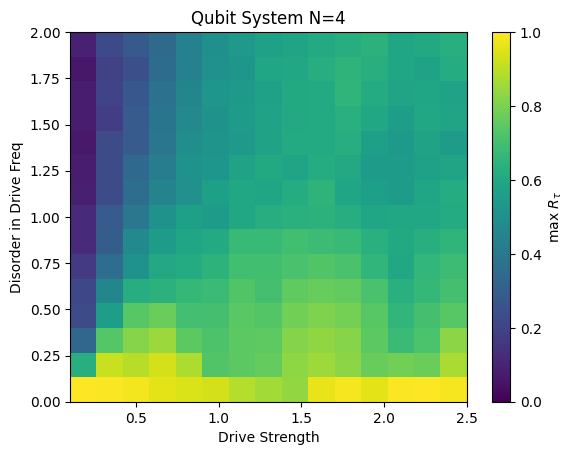

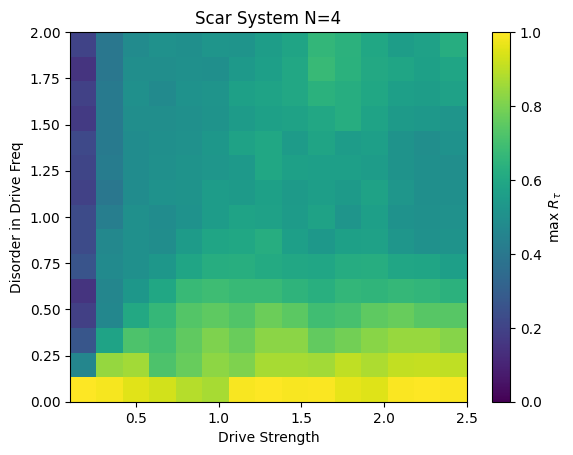

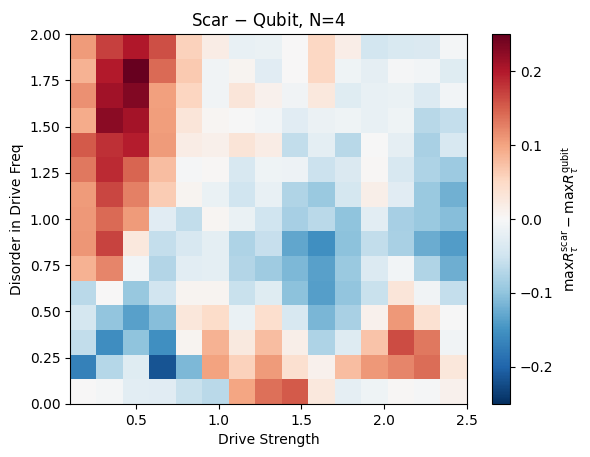

In [14]:
diff = disRtau - qdisRtau
lim = np.abs(diff).max()

plt.imshow(qdisRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label=r"max $R_\tau$")
plt.title(f"Qubit System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.savefig(f"figures/qubit_N{N}.pdf")
plt.show()

plt.imshow(disRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label=r"max $R_\tau$")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.savefig(f"figures/scar_N{N}.pdf")
plt.show()

plt.imshow(diff,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower', aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
plt.colorbar(label=r"$\max R_\tau^{\rm scar} - \max R_\tau^{\rm qubit}$")
plt.title(f"Scar $-$ Qubit, N={N}")
plt.ylabel("Disorder in Drive Freq")
plt.xlabel("Drive Strength")
plt.savefig(f"figures/diff_N{N}.pdf")
plt.show()